Healthcare Insurance Cost Analysis

This project explores the factors that influence medical insurance charges using a publicly available dataset.
The goal is to identify key drivers of insurance costs and provide insights that could help insurance companies improve pricing strategies.

Business Problem

Insurance companies need to understand which factors influence medical charges to price policies correctly.

This analysis answers questions such as:
- Does smoking increase insurance costs?
- Does BMI affect healthcare expenses?
- Which demographic groups have higher medical charges?

Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Step 2 — Load Dataset

In [2]:
PROJECT_ROOT = Path.cwd().parent   # notebook lives inside python_analysis/
DATA_PATH = PROJECT_ROOT / "data" / "insurance.csv"

df = pd.read_csv("D:\healthcare-insurance-analysis\insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Step 3 — Understand the Dataset

Before doing any analysis, we first look at:
- How big is the dataset? (rows and columns)
- What types of data do we have? (numbers vs categories)
- Is anything obviously wrong? (missing values, duplicates, inconsistent categories)

In [3]:
# Size of the dataset
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (1338, 7)


In [4]:
# Column names and data types
print("Data types:")
display(df.dtypes)

Data types:


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [5]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


Step 4 — Data Cleaning

We check for:
1. Missing values
2. Duplicate rows
3. Inconsistent category values (spelling errors, extra spaces)

In [6]:
# Check missing values
print("Missing values per column:")
display(df.isna().sum())

Missing values per column:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Insight: No missing values were found in this dataset.

If missing values did exist, we would handle them like this:
- Numeric columns → fill with mean: `df["bmi"].fillna(df["bmi"].mean(), inplace=True)`
- Categorical columns → fill with mode: `df["smoker"].fillna(df["smoker"].mode()[0], inplace=True)`

In [7]:
# Check and remove duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.duplicated().sum())

Duplicate rows: 1
After removing duplicates: 0


In [ ]:
# Check unique values in categorical columns
for col in ["sex", "smoker", "region"]:
    print(f"\n{col} unique values:")
    display(df[col].value_counts(dropna=False))


sex unique values:


sex
male      675
female    662
Name: count, dtype: int64


smoker unique values:


smoker
no     1063
yes     274
Name: count, dtype: int64


region unique values:


region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

Insight: All categorical values are consistent — no spelling errors or unexpected values.

Clean Dataset Summary:
- No missing values
- No duplicates
- Categorical variables are consistent
- Dataset is ready for analysis

Step 5 — Summary Statistics

We look at basic numbers to understand the dataset before plotting anything.
- Average, minimum, maximum
- Percentiles to spot skewness and outliers

In [9]:
# Full summary (numeric + categorical)
display(df.describe(include="all"))

,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450


In [10]:
# Percentiles for charges — shows skew and outlier range
percentiles = df["charges"].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("charges")
percentiles.index = ["p50 (median)", "p75", "p90", "p95", "p99"]
print("Charges percentiles:")
display(percentiles)

p95 = df["charges"].quantile(0.95)
print(f"\nThe top 5% of charges start at: ${p95:,.2f}")

Charges percentiles:


,charges
p50 (median),9386.161300
p75,16657.717450
p90,34832.741600
p95,41210.049800
p99,48537.796878



The top 5% of charges start at: $41,210.05


Insight: The average insurance charge is around $13,270. Some values exceed $60,000, indicating a right-skewed distribution — a small number of people have very high charges.

Step 6 — Univariate Analysis

Univariate = analyzing 'one variable at a time'.

We look at:
- Distribution (how values are spread)
- Central tendency (mean, median)
- Spread and potential outliers

Numerical Variables

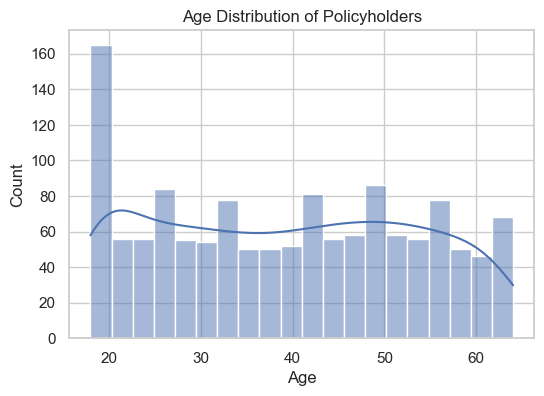

In [11]:
sns.set_theme(style="whitegrid")

# 1. Age distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution of Policyholders")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Insight: Most policyholders are between 18 and 40 years old.

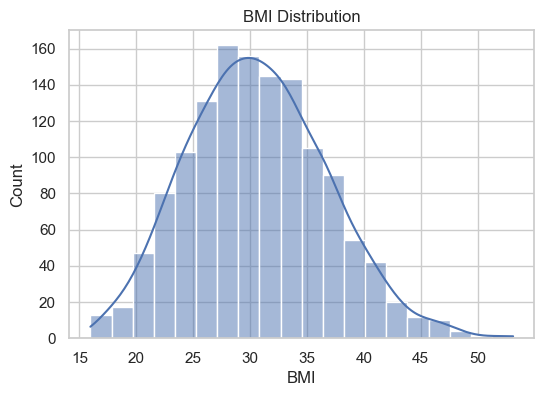

In [12]:
# 2. BMI distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["bmi"], bins=20, kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

Insight: Most individuals fall in the overweight range (BMI 25–30).

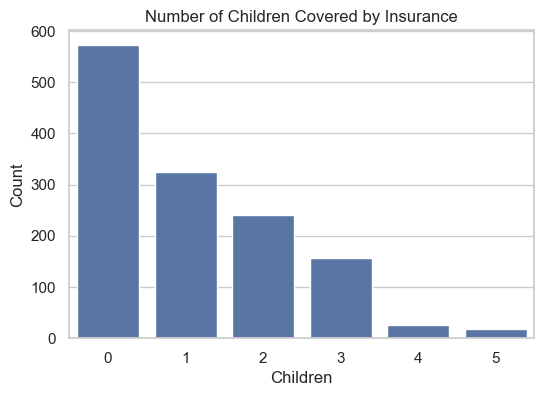

In [13]:
# 3. Children distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="children", data=df)
plt.title("Number of Children Covered by Insurance")
plt.xlabel("Children")
plt.ylabel("Count")
plt.show()

Insight: Most individuals have 0–2 children.

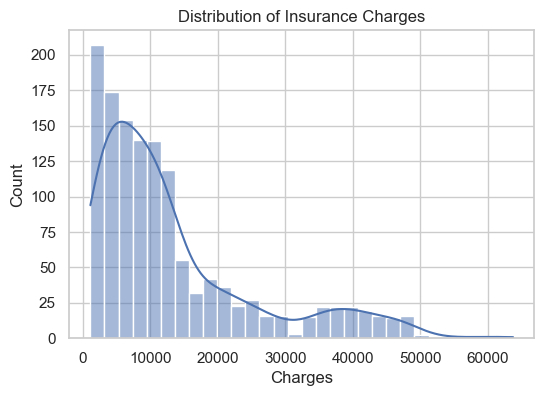

In [14]:
# 4. Charges distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["charges"], bins=30, kde=True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

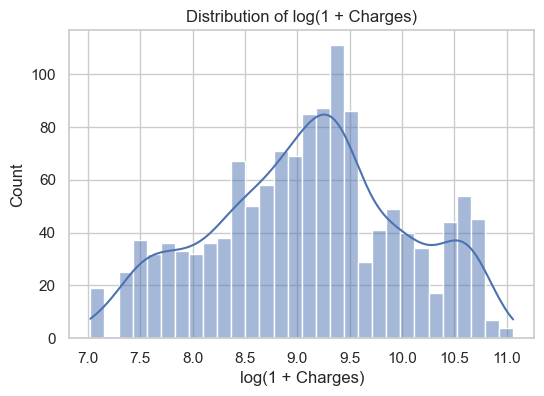

In [15]:
# Log scale version — helps visualize skewed data more clearly
plt.figure(figsize=(6, 4))
sns.histplot(np.log1p(df["charges"]), bins=30, kde=True)
plt.title("Distribution of log(1 + Charges)")
plt.xlabel("log(1 + Charges)")
plt.ylabel("Count")
plt.show()

Insight: Insurance charges are right-skewed — most people pay moderate amounts, but a small group pays very high charges.

Categorical Variables

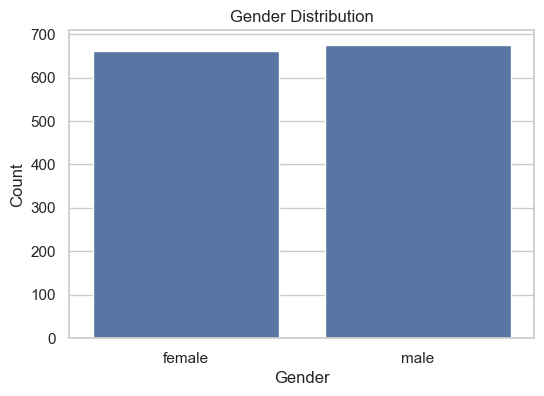

In [16]:
# Gender distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="sex", data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Insight: The dataset is roughly balanced between male and female policyholders.

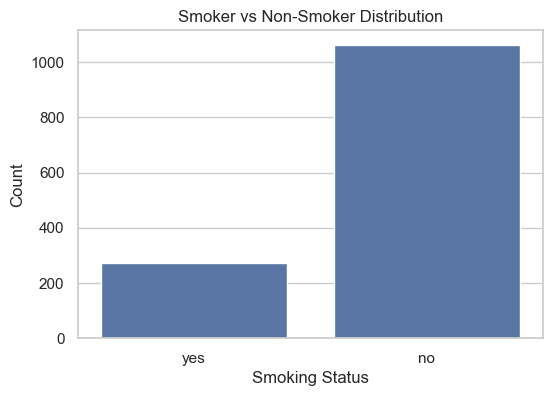

In [17]:
# Smoker distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="smoker", data=df)
plt.title("Smoker vs Non-Smoker Distribution")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.show()

Insight: Most individuals are non-smokers. Smokers are a minority in this dataset.

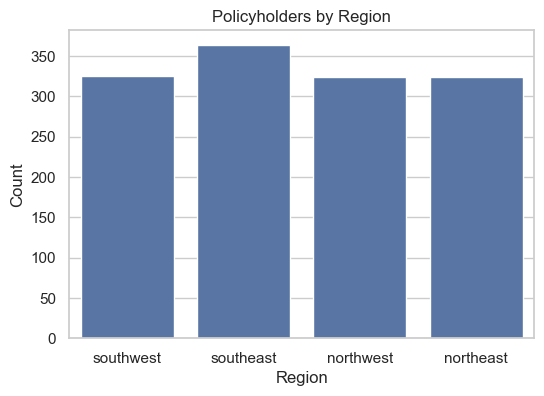

In [18]:
# Region distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="region", data=df)
plt.title("Policyholders by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

Insight: Policyholders are evenly distributed across all four regions.

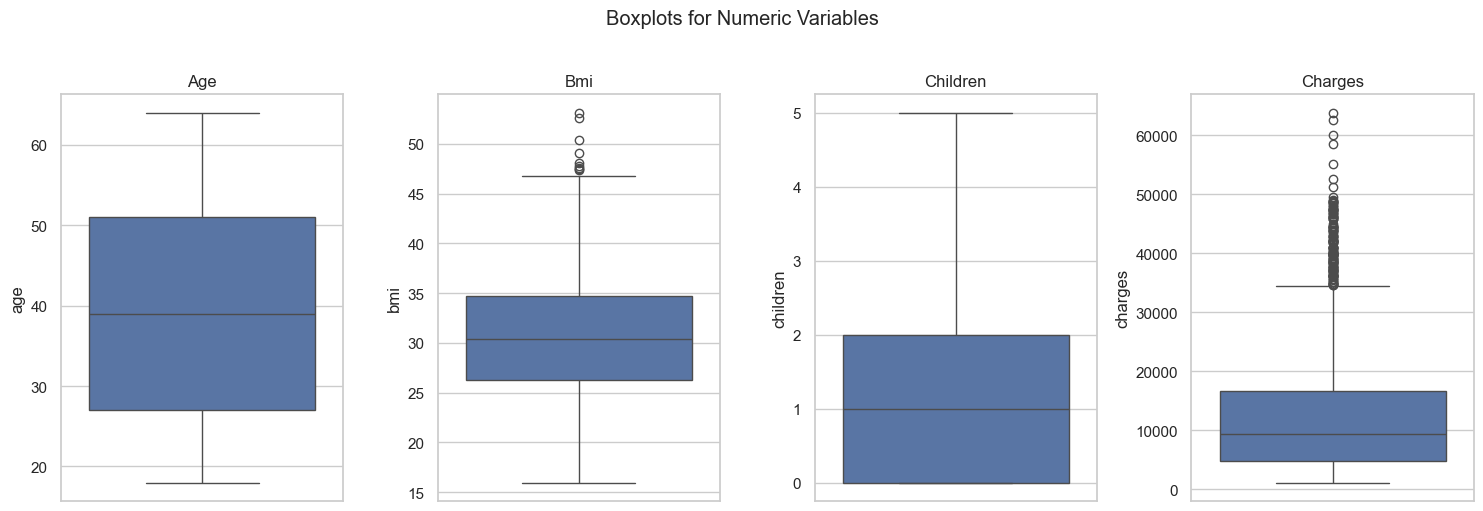

In [19]:
# Boxplots for all numeric columns — spots outliers at a glance
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, col in zip(axes, ["age", "bmi", "children", "charges"]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col.capitalize())
plt.suptitle("Boxplots for Numeric Variables", y=1.02)
plt.tight_layout()
plt.show()

Univariate Summary:
- Most policyholders are young adults (18–40 years)
- Many individuals fall in the overweight BMI range
- Most insured individuals have 0–2 children
- Insurance charges show strong right-skewness (a few very expensive cases)
- Dataset is balanced by gender and region

Step 7 — Outlier Detection

Outliers are extreme values much higher or lower than the rest of the data.
They can affect statistical analysis and machine learning models.

We will:
1. Spot them visually with boxplots
2. Measure them using the IQR method
3. Decide whether to keep or remove them

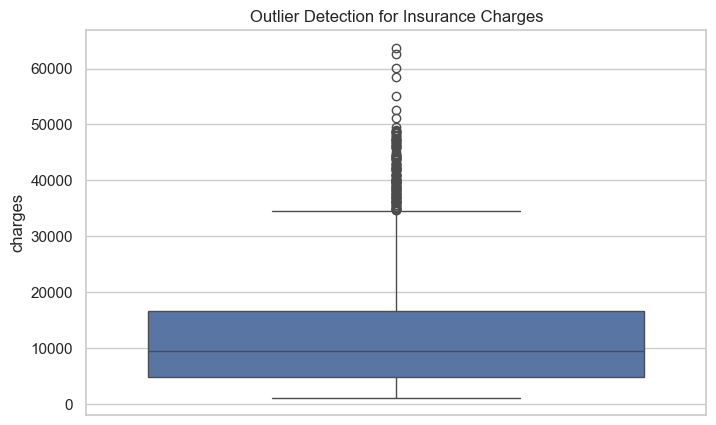

In [20]:
# Outlier check: Charges
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["charges"])
plt.title("Outlier Detection for Insurance Charges")
plt.show()

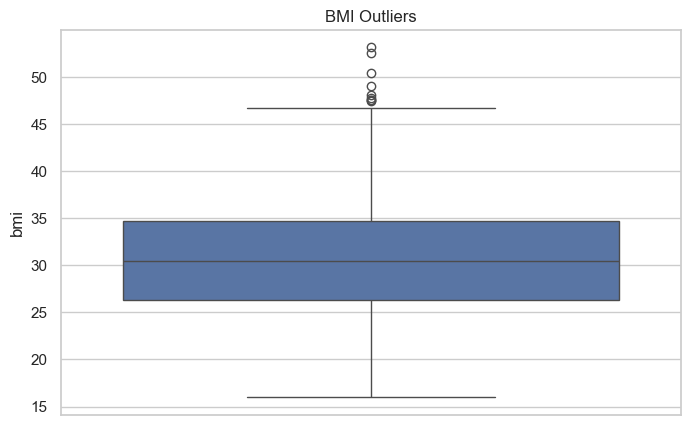

In [21]:
# Outlier check: BMI
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["bmi"])
plt.title("BMI Outliers")
plt.show()

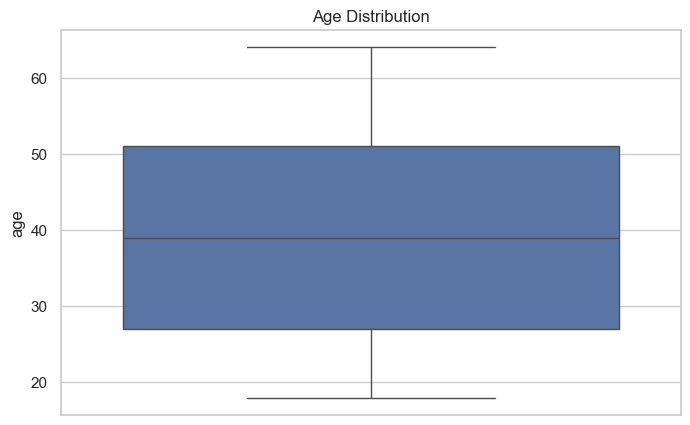

In [22]:
# Outlier check: Age
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["age"])
plt.title("Age Distribution")
plt.show()

In [23]:
# IQR method — counts how many values are extreme
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["charges"] < lower_bound) | (df["charges"] > upper_bound)]
print(f"Number of outliers in charges: {len(outliers)}")
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

Number of outliers in charges: 139
Lower bound: $-13,120.72
Upper bound: $34,524.78


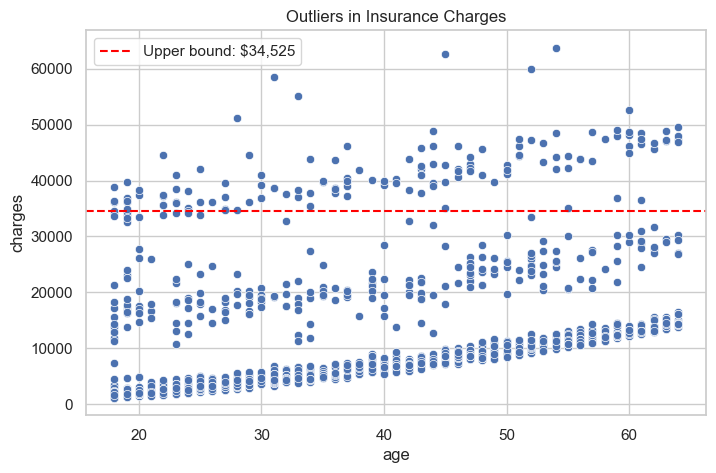

In [24]:
# Scatter plot highlighting where outliers sit
plt.figure(figsize=(8, 5))
sns.scatterplot(x="age", y="charges", data=df)
plt.axhline(upper_bound, color="red", linestyle="--", label=f"Upper bound: ${upper_bound:,.0f}")
plt.title("Outliers in Insurance Charges")
plt.legend()
plt.show()

Outlier Analysis Findings:
- Several high-value outliers exist in insurance charges
- These likely represent major surgeries, chronic illness, or long hospital stays
- Since these values are 'realistic' in healthcare data, we 'keep them'
- Removing real high-cost cases would make our model less useful in practice

Step 8 — Feature Engineering

Feature engineering means creating new columns from existing data to make analysis easier and more meaningful.

We will create:
- `bmi_category` — Underweight / Normal / Overweight / Obese
- `age_band` — grouped age ranges (18-25, 26-35, etc.)
- `is_high_risk` — 1 if person is both a smoker AND obese, else 0

In [25]:
# 1) BMI category
bmi_bins = [0, 18.5, 25, 30, np.inf]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese"]
df["bmi_category"] = pd.cut(df["bmi"], bins=bmi_bins, labels=bmi_labels, right=False)

print("Counts by BMI category:")
display(df["bmi_category"].value_counts(dropna=False))

Counts by BMI category:


bmi_category
Obese          706
Overweight     386
Normal         225
Underweight     20
Name: count, dtype: int64

In [26]:
# 2) Age band
age_bins = [18, 26, 36, 46, 56, 66, np.inf]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["age_band"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=False)

print("Counts by age band:")
display(df["age_band"].value_counts(dropna=False))

Counts by age band:


age_band
18-25    305
46-55    284
26-35    268
36-45    264
56-65    216
66+        0
Name: count, dtype: int64

In [27]:
# 3) High-risk flag: smoker + obese
df["is_high_risk"] = ((df["smoker"] == "yes") & (df["bmi_category"] == "Obese")).astype(int)

high_risk_pct = df["is_high_risk"].mean() * 100
print(f"High-risk segment: {high_risk_pct:.1f}% of customers")

High-risk segment: 10.8% of customers


In [28]:
# Quick check of new columns
display(df[["age", "age_band", "bmi", "bmi_category", "smoker", "is_high_risk", "charges"]].head(10))

,age,age_band,bmi,bmi_category,smoker,is_high_risk,charges
0,19,18-25,27.900,Overweight,yes,0,16884.92400
1,18,18-25,33.770,Obese,no,0,1725.55230
2,28,26-35,33.000,Obese,no,0,4449.46200
3,33,26-35,22.705,Normal,no,0,21984.47061
4,32,26-35,28.880,Overweight,no,0,3866.85520
5,31,26-35,25.740,Overweight,no,0,3756.62160
6,46,46-55,33.440,Obese,no,0,8240.58960
7,37,36-45,27.740,Overweight,no,0,7281.50560
8,37,36-45,29.830,Overweight,no,0,6406.41070
9,60,56-65,25.840,Overweight,no,0,28923.13692


In [29]:
# Business summaries using new features
print("Average charges by BMI category:")
display(df.groupby("bmi_category", observed=False)["charges"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False))

print("\nAverage charges by age band:")
display(df.groupby("age_band", observed=False)["charges"].agg(["count", "mean", "median"]))

print("\nAverage charges by high-risk flag:")
display(df.groupby("is_high_risk")["charges"].agg(["count", "mean", "median"]))

Average charges by BMI category:


,count,mean,median
bmi_category,,,
Obese,706,15572.041945,10003.654500
Overweight,386,10987.509891,8659.378000
Normal,225,10409.337709,8603.823400
Underweight,20,8852.200585,6759.262475



Average charges by age band:


,count,mean,median
age_band,,,
18-25,305,9111.433685,2639.042900
26-35,268,10495.163047,4900.581475
36-45,264,13493.485247,7442.572025
46-55,284,15986.900310,10477.962600
56-65,216,18795.993816,13429.650200
66+,0,NaN,NaN



Average charges by high-risk flag:


,count,mean,median
is_high_risk,,,
0,1192,9839.158474,8338.749175
1,145,41557.989840,40904.199500


- BMI insight: The highest average charges are in `_____` BMI category.
- Age insight: Charges generally `increase/decrease` as age increases.
- Risk segment: High-risk group is `_____%` of customers but has much `higher/lower` average charges.

Step 9 — Bivariate Analysis

Bivariate = analyzing **two variables together** to see how they relate.

We compare each feature against insurance charges to understand what drives costs.

In [ ]:
# 1. Age vs Charges
plt.figure(figsize=(8, 5))
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.show()

**Insight:** Insurance charges increase with age. Older individuals generally pay more.

In [ ]:
# 2. BMI vs Charges
plt.figure(figsize=(8, 5))
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

**Insight:** Higher BMI tends to slightly increase charges, likely due to obesity-related health risks.

In [ ]:
# 3. Smoker vs Charges — most important analysis
plt.figure(figsize=(8, 5))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Insurance Charges: Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

# Show actual numbers
smoker_stats = df.groupby("smoker")["charges"].agg(count="count", mean="mean", median="median")
display(smoker_stats)

ratio_median = smoker_stats.loc["yes", "median"] / smoker_stats.loc["no", "median"]
ratio_mean   = smoker_stats.loc["yes", "mean"]   / smoker_stats.loc["no", "mean"]
print(f"\nMedian ratio (smoker / non-smoker): {ratio_median:.2f}x")
print(f"Mean ratio   (smoker / non-smoker): {ratio_mean:.2f}x")

**Insight:** Smokers pay significantly more — often 3–4x higher than non-smokers. Smoking is the single strongest cost driver.

In [ ]:
# 4. Region vs Charges
plt.figure(figsize=(8, 5))
sns.boxplot(x="region", y="charges", data=df)
plt.title("Insurance Charges Across Regions")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.show()

region_summary = df.groupby("region")["charges"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
display(region_summary)

**Insight:** Regional differences are small compared to the smoking effect.

In [ ]:
# 5. Children vs Charges
plt.figure(figsize=(8, 5))
sns.boxplot(x="children", y="charges", data=df)
plt.title("Charges by Number of Children")
plt.xlabel("Children")
plt.ylabel("Charges")
plt.show()

**Insight:** The number of children does not significantly affect insurance charges.

In [ ]:
# Advanced: Age vs Charges split by smoking status
plt.figure(figsize=(8, 5))
sns.scatterplot(x="age", y="charges", hue="smoker", data=df)
plt.title("Age vs Charges (Smoker vs Non-Smoker)")
plt.show()

**Key Findings from Bivariate Analysis:**
- Smoking has the **strongest** effect on insurance charges
- Age shows a **positive** relationship with healthcare costs
- BMI slightly increases charges
- Region and number of children have minimal impact

## Step 10 — Multivariate Analysis

Multivariate = analyzing **three or more variables together** at the same time.

This helps us see combined effects — for example, does being a smoker with high BMI cost even more?

In [ ]:
# Combined view: Smoker + BMI category vs Charges
combo = (
    df.groupby(["smoker", "bmi_category"], observed=False)["charges"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=combo, x="bmi_category", y="mean", hue="smoker",
            order=["Underweight", "Normal", "Overweight", "Obese"])
plt.title("Average Charges by BMI Category and Smoking Status")
plt.xlabel("BMI Category")
plt.ylabel("Average Charges")
plt.show()

display(combo.sort_values("mean", ascending=False))

In [ ]:
# Pairplot with smoker color — shows all relationships at once
sns.pairplot(df[["age", "bmi", "children", "charges", "smoker"]], hue="smoker")
plt.suptitle("Pairplot: All Numeric Variables by Smoking Status", y=1.02)
plt.show()

In [ ]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(6, 4))
num_cols = ["age", "bmi", "children", "charges"]
corr = df[num_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

print("Note: Correlation is not causation. Use this as a direction signal, not final proof.")

In [ ]:
# BMI vs Charges split by Region
plt.figure(figsize=(8, 5))
sns.scatterplot(x="bmi", y="charges", hue="region", data=df)
plt.title("BMI vs Charges by Region")
plt.show()

**Multivariate Summary:**
- Smoking status strongly influences charges across all age groups and BMI levels
- The highest-cost segment is **smoker + obese**
- Age and BMI together gradually increase healthcare costs
- Regional differences remain minor compared to lifestyle factors

## Step 11 — Machine Learning Model (Linear Regression)

Now we build a model that **predicts insurance charges** based on a person's details.

Steps:
1. Select features and target variable
2. Split data into train and test sets
3. Build a preprocessing + model pipeline
4. Train the model
5. Evaluate using MAE, RMSE, and R²
6. Save the model for the Streamlit app

We use **Linear Regression** — the simplest and most explainable model, ideal for a first project.

In [ ]:
# Import all modeling libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

In [ ]:
# 1) Define features and target
feature_cols = ["age", "sex", "bmi", "children", "smoker", "region"]
target_col = "charges"

X = df[feature_cols].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

In [ ]:
# 2) Train/test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train rows:", len(X_train))
print("Test rows: ", len(X_test))

In [ ]:
# 3) Preprocessing: encode categorical columns, pass numeric through unchanged
categorical_features = ["sex", "smoker", "region"]
numeric_features = ["age", "bmi", "children"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", "passthrough", numeric_features),
])

# 4) Full pipeline: preprocessing + model in one step
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])

model_pipeline.fit(X_train, y_train)
print("Model trained successfully.")

In [ ]:
# 5) Evaluate the model
y_pred = model_pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : ${mae:,.2f}   (average prediction error)")
print(f"RMSE : ${rmse:,.2f}  (penalises large errors more)")
print(f"R²   : {r2:.4f}     (how much variance is explained; closer to 1 = better)")

In [ ]:
# Actual vs predicted — first 10 rows
comparison = pd.DataFrame({
    "actual"    : y_test.values,
    "predicted" : y_pred,
    "abs_error" : abs(y_test.values - y_pred)
}).head(10)

display(comparison)

In [ ]:
# Scatter plot: actual vs predicted (good model = points near red line)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], "r--", label="Perfect prediction")
plt.legend()
plt.show()

In [ ]:
from pathlib import Path

# Define the absolute path directly
model_out_path = Path("D:/healthcare-insurance-analysis/model/medical_cost_model.pkl")

# Create parent directory if it doesn't exist
model_out_path.parent.mkdir(parents=True, exist_ok=True)

# Save the model
with open(model_out_path, "wb") as f:
    pickle.dump(model_pipeline, f)

print(f"Model saved to: {model_out_path}")